In [4]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import matplotlib
import torch
import logging 
from pathlib import Path
import random
import numpy as np

import method.datasets as ds
import method.preprocess.preprocess as ps
import method.core.pipeline as pipe
import method.models.rnn.rnn as model

from method.metrics import metrics
from logging_tools.config import setup_logging
from method.viz import plot_data, plot_results, plot_data_compare

import data_configs.test_data_config as test_config
import data_configs.base_raw_data as config

CONFIGS_PATH = Path("configs")
DATASET_CONFIG = ds.DatasetConfig.from_dict(config.EXECUTE_CONFIG["dataset"])

setup_logging()
logger = logging.getLogger(__name__)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


INFO     Preprocessor.transform start

INFO     Pipeline making step 'drop_intervals'

INFO     Pipeline making step 'filter'

INFO     Pipeline making step 'scaler'

INFO     Pipeline making step 'feature_selector'

INFO     Pipeline making step 'splitter'

INFO     Preprocessor.transform end (1.77)s

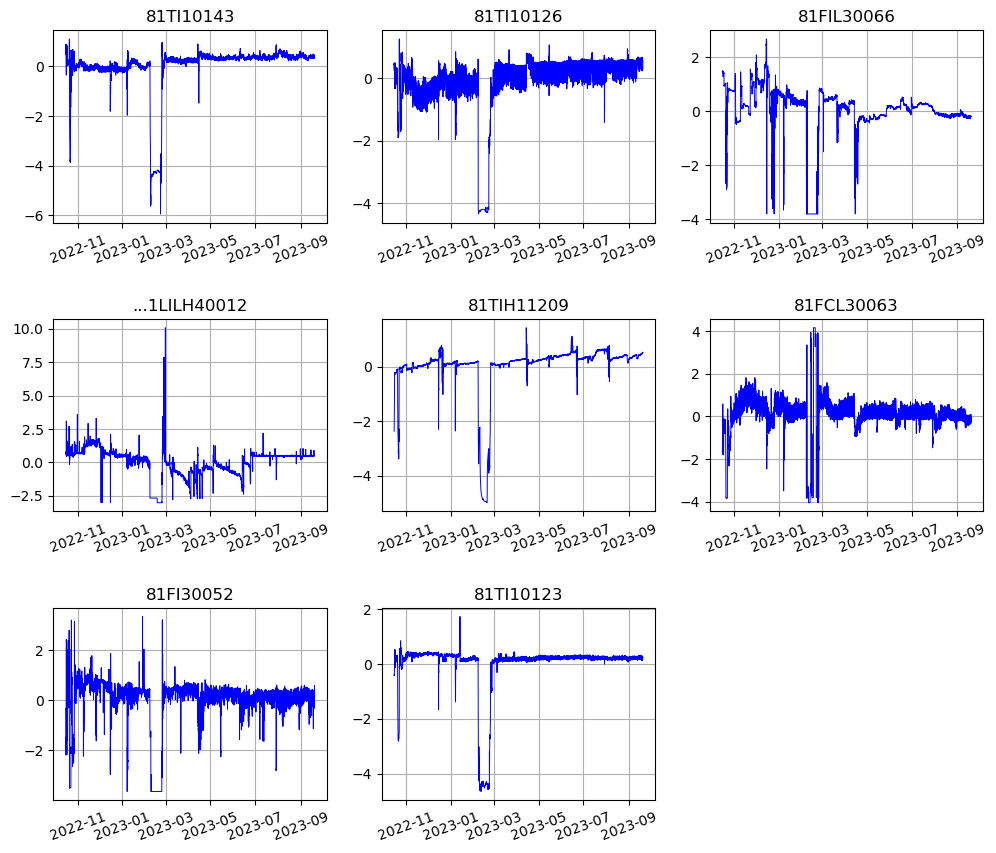

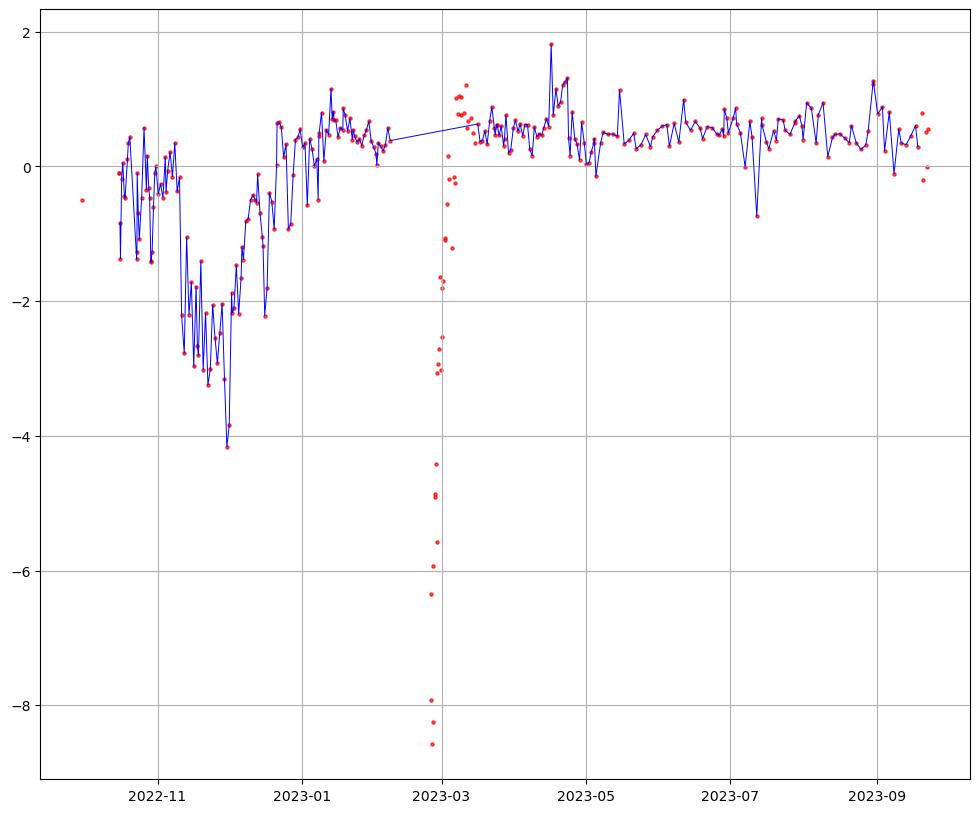

In [5]:
data_raw = ds.LoadDatasetStep(DATASET_CONFIG).fit_transform()

preprocess_config = ps.PreprocessConfig.from_dict(config.EXECUTE_CONFIG["preprocess"])
preprocessor = ps.Preprocessor(preprocess_config)

data = preprocessor.fit_transform(data_raw)
data_merged = data.merge_data()
ds_raw = data_raw.train.replace(new_y_scaler=data.train.y_scaler)
target_raw_scaled = ds_raw.scale(scale_y=True).y
target = data_merged.train.y
plot_data(data_merged.train.X.dropna(), plot_type="plot")
plot_data_compare(target_raw_scaled.dropna(), target.dropna())

INFO     RNN training model

INFO     Computing best lag using spearman correlation...

INFO     epoch 0: train: 1.7691, lr: 1.000e-02, valid: 0.3616, best_valid: 0.3616

INFO     epoch 10: train: 0.2603, lr: 1.000e-02, valid: 0.0814, best_valid: 0.0814

INFO     epoch 20: train: 0.1429, lr: 1.000e-02, valid: 0.1692, best_valid: 0.0807

...

INFO     epoch 160: train: 0.0751, lr: 1.000e-02, valid: 0.2526, best_valid: 0.0771

INFO     epoch 170: train: 0.0399, lr: 1.000e-02, valid: 0.2598, best_valid: 0.0771

INFO     epoch 180: train: 0.0995, lr: 1.000e-02, valid: 0.2552, best_valid: 0.0771

INFO     epoch 190: train: 0.0307, lr: 1.000e-02, valid: 0.3234, best_valid: 0.0771

INFO     RNN Model trained

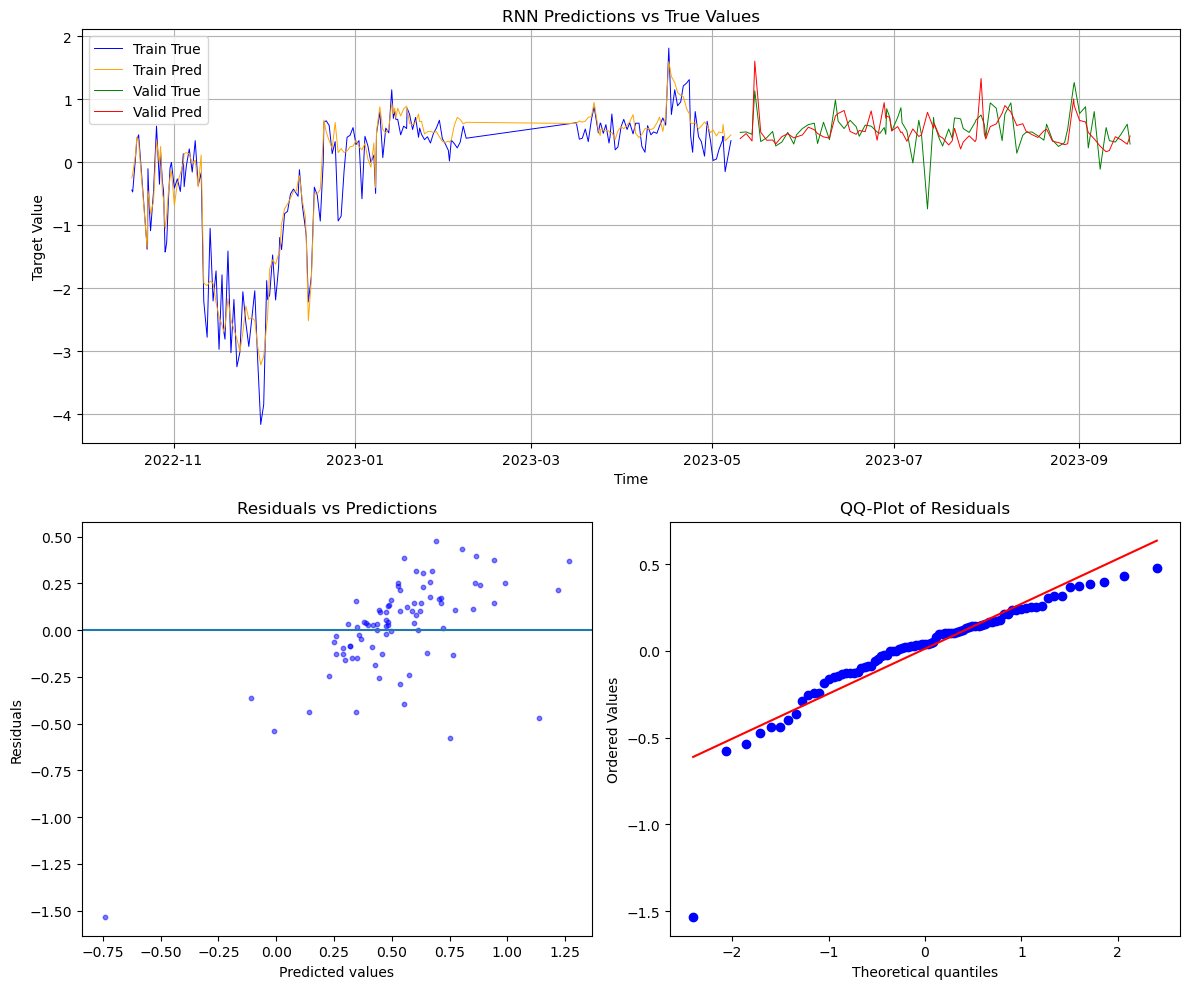

INFO                                                                                                               
         Metrics for Train:

INFO                                                                                                               
         Metrics for Valid:

INFO     MAE                  0.191487                                                                             
         rMSE                 0.277690                                                                             
         MAPE                 1.011739                                                                             
         Pearson (p-value)    0.000095                                                                             
         Pearson              0.410648                                                                             
         R2                  -0.023642                                                                             
         Hinge                0.109924                                                                             
         dtype: float64

In [6]:

torch.manual_seed(0)
np.random.seed(42)
random.seed(42)

# data_loader = ds.LoadDatasetStep(DATASET_CONFIG)
# preprocess_config = ps.PreprocessConfig.from_dict(config.EXECUTE_CONFIG["preprocess"])
# preprocessor = ps.Preprocessor(preprocess_config)

rnn_config = model.RNNConfig.from_dict(config.EXECUTE_CONFIG["model"])
rnn = model.RNN(rnn_config)

steps = [
    # ("data_loader", data_loader),
    # ("preprocessor", preprocessor),
    ("rnn", rnn),
]
full_pipeline = pipe.Pipeline(steps) # type: ignore
result = full_pipeline.fit_transform(data)

plot_results(result)

logger.info("\nMetrics for Train:")
logger.debug(metrics(**result["train"], cone=0.1))
logger.info("\nMetrics for Valid:")
logger.info(metrics(**result["valid"], cone=0.1))